In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# clean visual style for later
sns.set_style("whitegrid")

#load the data
df = pd.read_csv(r"C:\Users\muniz\Documents\stroke_prediction\dataset\healthcare-dataset-stroke-data.csv")

# inital inspection of the data
print("---- first five rows -----")
display(df.head(5))

# dataset shapes
print("---- dataset shape -----")
print(df.shape)

# missing values count
print("---- missing values count -----  ")
display(df.isnull().sum())

# variable distribution 
print("---- variable distribution: Stroke vs No stroke ")
display(df['stroke'].value_counts(normalize=True) * 100)

---- first five rows -----


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


---- dataset shape -----
(5110, 12)
---- missing values count -----  


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

---- variable distribution: Stroke vs No stroke 


stroke
0    95.127202
1     4.872798
Name: proportion, dtype: float64

In [2]:
# median value for the missing BMI numbers
median_bmi = df['bmi'].median()
df['bmi'] = df['bmi'].fillna(median_bmi)

# unknown collumn in the smoking status variable, we will replace it with the mode of the variable
mode_smoking = df['smoking_status'].mode()[0]
df['smoking_status'] = df['smoking_status'].replace('Unknown', mode_smoking)

# check if the cleaning was successful
print(" ----- Updated missing values count ----- ")
display(df.isnull().sum())

print("\n updated smoking status counts")
display(df['smoking_status'].value_counts())

 ----- Updated missing values count ----- 


id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


 updated smoking status counts


smoking_status
never smoked       3436
formerly smoked     885
smokes              789
Name: count, dtype: int64

bellow is the transforming of the text values to numerics ones for the model training

In [12]:
df_encoded = pd.get_dummies(df, columns =
                            ['gender',
                                                          'ever_married',
                             'work_type',
                             'Residence_type',
                            'smoking_status'], drop_first=True) # this prevents reduntant duplicate columns in the dataset
                            

# separating features and targets
X = df_encoded.drop('stroke', axis=1) # everything except the target
y = df_encoded['stroke'] # onyl target

# verify the transformation
print(" --- New dataset shape ---")
print(X.shape)

print("\n first 3 rows of encoded features")
display (X.head(3))

print("\n target variable (y) check")
display(y.head(3))

 --- New dataset shape ---
(5110, 16)

 first 3 rows of encoded features


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,gender_Other,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,228.69,36.6,True,False,True,False,True,False,False,True,False,False
1,51676,61.0,0,0,202.21,28.1,False,False,True,False,False,True,False,False,True,False
2,31112,80.0,0,1,105.92,32.5,True,False,True,False,True,False,False,False,True,False



 target variable (y) check


0    1
1    1
2    1
Name: stroke, dtype: int64

here we'll split the data in the 80/20 method and scale the numbers properly

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# split the data 80 train and 20 test
# stratify=y is crucial in healthcare and here, it ensures both sets have the same 4.87% stroke ratio
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scaling the features so they are on the same playing field
scaler = StandardScaler()

# fir on training data, then transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# verifying the split
print(" --- Training set shape - rows and columns ---")
print(X_train_scaled.shape)

print("\n --- test set shape = rows and columns ---")
print(X_test_scaled.shape)

 --- Training set shape - rows and columns ---
(4088, 16)

 --- test set shape = rows and columns ---
(1022, 16)


we'll use random forest classifier

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, recall_score

# initialize the model 
# random_state=42 keeps our results reproducible
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# model fit
model.fit(X_train_scaled, y_train)

# make predictions on the unseen test data
y_pred = model.predict(X_test_scaled)

# evaluate the model
print(" --- model accuracy score ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print(" --- model recall (crucial in healthcare) ---")
print(f"recall for stroke (class 1): {recall_score(y_test, y_pred, pos_label = 1):.4f}\n")

print(" --- full classification report ---")
print(classification_report(y_test, y_pred))


 --- model accuracy score ---
Accuracy: 0.9432

 --- model recall (crucial in healthcare) ---
recall for stroke (class 1): 0.0600

 --- full classification report ---
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       972
           1       0.21      0.06      0.09        50

    accuracy                           0.94      1022
   macro avg       0.58      0.52      0.53      1022
weighted avg       0.92      0.94      0.93      1022



the model accurary is 94. this isnt great, its "lazy", it basically means it classified by "luck" and left out the actual sick people; 
50 * 0.06 = 3 the model only saw 3 people out of the 50 who had strokes

due to this we now will apply the SMOTE techinique

In [15]:
from imblearn.over_sampling import SMOTE

# apply smote to the training data only! 
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

# checking new balance
print(" --- new training data balance ---")
display(pd.Series(y_train_smote).value_counts())

# retrain the model on the new balanced data
model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

# predict on the test data
y_pred_smote = model_smote.predict(X_test_scaled)

# evaluate the model
print(" --- NEW model accuracy score ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_smote):.4f}\n")

print(" --- new model recall ---")
print(f"Recall for stroke (class 1): {recall_score(y_test, y_pred_smote, pos_label=1):.4f}\n")

print(" --- NEW full classification report ---")
print(classification_report(y_test, y_pred_smote))

 --- new training data balance ---


stroke
0    3889
1    3889
Name: count, dtype: int64

 --- NEW model accuracy score ---
Accuracy: 0.9227

 --- new model recall ---
Recall for stroke (class 1): 0.1800

 --- NEW full classification report ---
              precision    recall  f1-score   support

           0       0.96      0.96      0.96       972
           1       0.19      0.18      0.19        50

    accuracy                           0.92      1022
   macro avg       0.57      0.57      0.57      1022
weighted avg       0.92      0.92      0.92      1022



C:\Users\muniz\AppData\Local\Temp\ipykernel_3296\3207532067.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


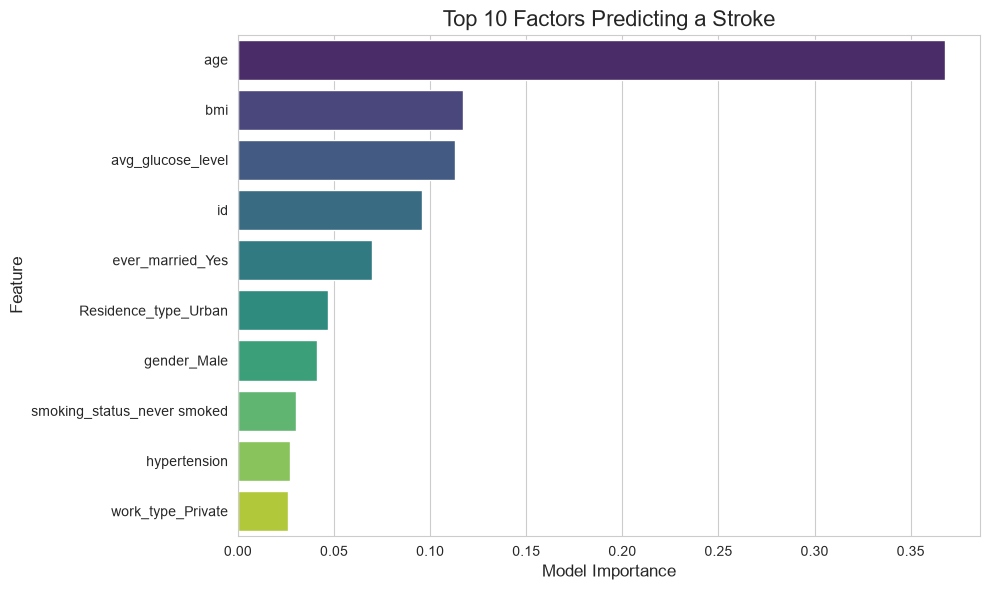

In [7]:
# 1. Extract how important each feature was to the model
importances = model_smote.feature_importances_
feature_names = X.columns # Get the actual column names

# 2. Put them in a neat table and sort them from most important to least
feature_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_df = feature_df.sort_values(by='Importance', ascending=False)

# 3. Plot the top 10 most important clues!
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title('Top 10 Factors Predicting a Stroke', fontsize=16)
plt.xlabel('Model Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# get predicted model probabilities
y_prob = model_smote.predict_proba(X_test_scaled)[:,1] # possibilities for class 1 stroke

# lower the threshold to 0.3 instead of deafault 0.5 to catch more stroke cases
y_pred_threshold = (y_prob >= 0.3).astype(int)

# evaluate new results with the lowered threshold
print(" --- model recall at threshold 0.3 ---")
print(f"Recall for stroke (class 1): {recall_score(y_test, y_pred_threshold, pos_label=1):.4f}\n")

print(" --- full classification report at threshold 0.3 ---")
print(classification_report(y_test, y_pred_threshold))

 --- model recall at threshold 0.3 ---
Recall for stroke (class 1): 0.4400

 --- full classification report at threshold 0.3 ---
              precision    recall  f1-score   support

           0       0.97      0.86      0.91       972
           1       0.14      0.44      0.21        50

    accuracy                           0.84      1022
   macro avg       0.55      0.65      0.56      1022
weighted avg       0.93      0.84      0.87      1022

